In [1]:
# Imports

from pathlib import Path
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load predictions

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

test_output = pd.read_pickle(PROCESSED_DIR / "test_predictions.pkl")

test_output.shape

(200000, 24)

In [3]:
# Define business topic taxonomy
# This is a pragmatic first version. It can later be replaced with BERTopic or a supervised topic model.

TOPIC_KEYWORDS = {
    "Food Quality": [
        "food", "taste", "delicious", "cold", "fresh", "overcooked", "undercooked",
        "pizza", "pasta", "burger", "sushi", "meal", "dish"
    ],
    "Service": [
        "services", "staff", "waiter", "waitress", "server", "manager",
        "rude", "friendly", "polite", "attentive"
    ],
    "Waiting Time": [
        "wait", "waiting", "minutes", "hour", "line", "queue", "slow",
        "reservation", "table"
    ],
    "Price": [
        "price", "expensive", "cheap", "overpriced", "value", "money", "cost"
    ],
    "Cleanliness": [
        "clean", "dirty", "bathroom", "restroom", "smell", "hygiene"
    ],
    "Atmosphere": [
        "atmosphere", "ambience", "music", "noise", "loud", "cozy", "decor",
        "vibe"
    ],
    "Parking": [
        "parking", "park", "garage", "valet"
    ]
}

In [4]:
# Topic detection function

def detect_topics(text):
    """
    Detect business topics using keyword matching.
    This is intentionally interpretable for a first business-facing prototype.
    """
    text = str(text).lower()
    detected_topics = []

    for topic, keywords in TOPIC_KEYWORDS.items():
        for keyword in keywords:
            pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
            if re.search(pattern, text):
                detected_topics.append(topic)
                break

    if not detected_topics:
        detected_topics.append("Other")

    return detected_topics

In [5]:
# Apply topic detection

test_output["detected_topics"] = test_output["review_text"].apply(detect_topics)

topic_level_df = test_output.explode("detected_topics").rename(
    columns={"detected_topics": "topic"}
)

topic_level_df[["review_text", "topic", "predicted_sentiment"]].head()

,review_text,topic,predicted_sentiment
0,The customer service here was terrible. There ...,Food Quality,negative
0,The customer service here was terrible. There ...,Service,negative
0,The customer service here was terrible. There ...,Waiting Time,negative
1,EDITED (9/14/2021) TO ADD: Please note the of...,Service,negative
1,EDITED (9/14/2021) TO ADD: Please note the of...,Waiting Time,negative


In [6]:
%%time

# Severity scoring
# High severity means negative sentiment plus strong complaint language.

HIGH_SEVERITY_PATTERNS = [
    "never again",
    "worst",
    "terrible",
    "horrible",
    "disgusting",
    "left without",
    "waited",
    "rude",
    "cold food",
    "dirty"
]

def calculate_severity(row):
    """
    Assign severity based on predicted sentiment and complaint signals.
    """
    text = str(row["review_text"]).lower()
    sentiment = row["predicted_sentiment"]

    if sentiment == "positive":
        return "low"

    severity_score = 0

    if sentiment == "negative":
        severity_score += 2

    if row.get("review_word_count", 0) > 120:
        severity_score += 1

    for pattern in HIGH_SEVERITY_PATTERNS:
        if pattern in text:
            severity_score += 1

    if severity_score >= 3:
        return "high"
    elif severity_score == 2:
        return "medium"
    else:
        return "low"


topic_level_df["severity"] = topic_level_df.apply(calculate_severity, axis=1)

topic_level_df[["topic", "predicted_sentiment", "severity"]].head()

CPU times: user 2.12 s, sys: 42.8 ms, total: 2.16 s
Wall time: 2.16 s


,topic,predicted_sentiment,severity
0,Food Quality,negative,high
0,Service,negative,high
0,Waiting Time,negative,high
1,Service,negative,high
1,Waiting Time,negative,high


In [7]:
%%time

# Business-level aggregation

business_insights = (
    topic_level_df
    .groupby(["business_id", "business_name", "city", "state", "topic"])
    .agg(
        review_count=("review_id", "count"),
        negative_count=("predicted_sentiment", lambda x: (x == "negative").sum()),
        neutral_count=("predicted_sentiment", lambda x: (x == "neutral").sum()),
        positive_count=("predicted_sentiment", lambda x: (x == "positive").sum()),
        high_severity_count=("severity", lambda x: (x == "high").sum())
    )
    .reset_index()
)

business_insights["negative_ratio"] = (
    business_insights["negative_count"] / business_insights["review_count"]
)

business_insights.sort_values(
    ["high_severity_count", "negative_ratio"],
    ascending=False
).head(20)

CPU times: user 14.8 s, sys: 99.2 ms, total: 14.9 s
Wall time: 15.2 s


,business_id,business_name,city,state,topic,review_count,negative_count,neutral_count,positive_count,high_severity_count,negative_ratio
50557,K2O1HIsqg-gB_ciFtcqybg,Intelcom Express,Edmonton,AB,Service,28,27,1,0,23,0.964286
144795,wz8ZPfySQczcPgSyd33-HQ,Grand Sierra Resort and Casino,Reno,NV,Waiting Time,32,22,5,5,20,0.687500
6385,1Vo4BLw75ntATAJHYsxO3g,Whiskey Joe's Bar & Grill - Tampa,Tampa,FL,Service,47,21,16,10,18,0.446809
144794,wz8ZPfySQczcPgSyd33-HQ,Grand Sierra Resort and Casino,Reno,NV,Service,31,20,4,7,16,0.645161
66055,QktYpHYLMm_HEUvcNNE6Fw,"Republic Services of Tucson, AZ",Tucson,AZ,Service,22,21,0,1,15,0.954545
73399,TvbJq1a1Xto5w6t4zMUYHQ,Vessel NOLA,New Orleans,LA,Waiting Time,27,17,5,5,15,0.629630
6386,1Vo4BLw75ntATAJHYsxO3g,Whiskey Joe's Bar & Grill - Tampa,Tampa,FL,Waiting Time,37,20,13,4,15,0.540541
69571,SJIQFKTW6uUsOo29w9IHxw,Mambo's,New Orleans,LA,Waiting Time,58,19,10,29,15,0.327586
6072,1P2LJR7pdttVgTObeMtkog,Vanguard Group,Malvern,PA,Waiting Time,18,18,0,0,14,1.000000
27396,AGlh4ZDv6jnoiYfz7At9mw,Dim Sum Garden,Philadelphia,PA,Food Quality,52,23,8,21,14,0.442308


In [10]:
# Pick one example business with enough reviews

business_review_counts = (
    test_output
    .groupby(["business_id", "business_name", "city", "state"])
    .agg(review_count=("review_id", "count"))
    .reset_index()
    .sort_values("review_count", ascending=False)
)

example_business = business_review_counts.iloc[0]

example_business

business_id          oBNrLz4EDhiscSlbOl8uAw
business_name    Ruby Slipper - New Orleans
city                            New Orleans
state                                    LA
review_count                            215
Name: 46017, dtype: object

In [11]:
%%time

# Generate dashboard-style summary for one business

example_business_id = example_business["business_id"]

example_reviews = test_output[
    test_output["business_id"] == example_business_id
].copy()

example_topic_rows = topic_level_df[
    topic_level_df["business_id"] == example_business_id
].copy()

overall_sentiment = (
    example_reviews["predicted_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

overall_sentiment.columns = ["sentiment", "percentage"]

topic_summary = (
    example_topic_rows
    .groupby("topic")
    .agg(
        review_count=("review_id", "count"),
        negative_ratio=("predicted_sentiment", lambda x: (x == "negative").mean()),
        high_severity_count=("severity", lambda x: (x == "high").sum())
    )
    .reset_index()
    .sort_values(["high_severity_count", "negative_ratio", "review_count"], ascending=False)
)

overall_sentiment, topic_summary.head(10)

CPU times: user 51.2 ms, sys: 3.76 ms, total: 54.9 ms
Wall time: 54.9 ms


(  sentiment  percentage
 0  positive        86.5
 1  negative         7.9
 2   neutral         5.6,
           topic  review_count  negative_ratio  high_severity_count
 2  Food Quality           153        0.071895                    7
 6       Service           124        0.064516                    5
 3         Other            21        0.190476                    2
 0    Atmosphere            28        0.071429                    1
 7  Waiting Time            84        0.059524                    1
 5         Price             7        0.142857                    0
 1   Cleanliness             2        0.000000                    0
 4       Parking             1        0.000000                    0)

In [12]:
# Extract representative reviews for top complaint topics

top_complaint_topics = topic_summary.head(3)["topic"].tolist()

representative_reviews = (
    example_topic_rows[
        (example_topic_rows["topic"].isin(top_complaint_topics)) &
        (example_topic_rows["predicted_sentiment"] == "negative")
    ]
    .sort_values(["severity", "review_word_count"], ascending=False)
    [
        [
            "topic",
            "severity",
            "review_text",
            "predicted_sentiment",
            "review_date"
        ]
    ]
    .head(10)
)

representative_reviews

,topic,severity,review_text,predicted_sentiment,review_date
31270,Food Quality,medium,This place seems to have quite the buzz. I sat...,negative,2021-10-04 16:23:57
31270,Service,medium,This place seems to have quite the buzz. I sat...,negative,2021-10-04 16:23:57
75257,Food Quality,medium,This place is very OK. I'm a New Orleans nativ...,negative,2021-11-01 16:10:19
75257,Service,medium,This place is very OK. I'm a New Orleans nativ...,negative,2021-11-01 16:10:19
36241,Food Quality,medium,Don't wast your time or money. The breakfast h...,negative,2021-10-07 21:23:10
78152,Service,medium,The service wasn't great . We sat inside and h...,negative,2021-11-03 18:15:08
162623,Food Quality,medium,Don't bother coming here if you don't have 3 h...,negative,2021-12-29 00:53:19
117882,Food Quality,medium,We received great service from our waiter but ...,negative,2021-11-29 19:54:16
117882,Service,medium,We received great service from our waiter but ...,negative,2021-11-29 19:54:16
112789,Other,medium,"Un poco ocupado , pero no fue mucho la espera ...",negative,2021-11-26 08:54:22


In [13]:
# Rule-based action recommendations
# In a production version, this can be replaced by an LLM over aggregated topic insights.

ACTION_MAP = {
    "Waiting Time": "Investigate staffing and table turnover during peak hours.",
    "Food Quality": "Review kitchen quality control and food temperature before serving.",
    "Service": "Review staff training and manager escalation process.",
    "Price": "Check whether customers perceive the offer as good value for money.",
    "Cleanliness": "Audit cleaning routines, especially restrooms and high-traffic areas.",
    "Atmosphere": "Review noise level, music, seating comfort, and ambience.",
    "Parking": "Improve parking instructions or communicate nearby parking alternatives.",
    "Other": "Manually review representative negative reviews to identify emerging issues."
}

topic_summary["recommended_action"] = topic_summary["topic"].map(ACTION_MAP)

topic_summary.head(10)

,topic,review_count,negative_ratio,high_severity_count,recommended_action
2,Food Quality,153,0.071895,7,Review kitchen quality control and food temper...
6,Service,124,0.064516,5,Review staff training and manager escalation p...
3,Other,21,0.190476,2,Manually review representative negative review...
0,Atmosphere,28,0.071429,1,"Review noise level, music, seating comfort, an..."
7,Waiting Time,84,0.059524,1,Investigate staffing and table turnover during...
5,Price,7,0.142857,0,Check whether customers perceive the offer as ...
1,Cleanliness,2,0.000000,0,"Audit cleaning routines, especially restrooms ..."
4,Parking,1,0.000000,0,Improve parking instructions or communicate ne...


In [16]:
# Create final business-facing output

dashboard_output = {
    "business_name": example_business["business_name"],
    "city": example_business["city"],
    "state": example_business["state"],
    "number_of_reviews_analyzed": len(example_reviews),
    "overall_sentiment": overall_sentiment.to_dict(orient="records"),
    "top_topics": topic_summary.head(10).to_dict(orient="records"),
    "representative_negative_reviews": representative_reviews.to_dict(orient="records")
}

dashboard_output

{'business_name': 'Ruby Slipper - New Orleans',
 'city': 'New Orleans',
 'state': 'LA',
 'number_of_reviews_analyzed': 215,
 'overall_sentiment': [{'sentiment': 'positive', 'percentage': 86.5},
  {'sentiment': 'negative', 'percentage': 7.9},
  {'sentiment': 'neutral', 'percentage': 5.6}],
 'top_topics': [{'topic': 'Food Quality',
   'review_count': 153,
   'negative_ratio': 0.0718954248366013,
   'high_severity_count': 7,
   'recommended_action': 'Review kitchen quality control and food temperature before serving.'},
  {'topic': 'Service',
   'review_count': 124,
   'negative_ratio': 0.06451612903225806,
   'high_severity_count': 5,
   'recommended_action': 'Review staff training and manager escalation process.'},
  {'topic': 'Other',
   'review_count': 21,
   'negative_ratio': 0.19047619047619047,
   'high_severity_count': 2,
   'recommended_action': 'Manually review representative negative reviews to identify emerging issues.'},
  {'topic': 'Atmosphere',
   'review_count': 28,
   'ne

In [17]:
# Save dashboard output tables

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

overall_sentiment.to_csv(OUTPUT_DIR / "overall_sentiment_example_business.csv", index=False)
topic_summary.to_csv(OUTPUT_DIR / "topic_summary_example_business.csv", index=False)
representative_reviews.to_csv(OUTPUT_DIR / "representative_reviews_example_business.csv", index=False)

print("Dashboard outputs saved.")

Dashboard outputs saved.


In [18]:
results_df = pd.read_csv("../data/processed/ablation_results.csv")
results_df.head()

,model_name,accuracy,macro_f1,weighted_f1
0,review_plus_categories,0.868965,0.747216,0.881414
1,review_only,0.869580,0.746730,0.881670
2,full_context_with_numeric,0.844525,0.719202,0.859024
3,review_plus_categories_tips,0.843675,0.717998,0.858166


In [19]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_true = test_output["target_sentiment"]
y_pred = test_output["predicted_sentiment"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))

print(classification_report(y_true, y_pred))

Accuracy: 0.87358
Macro F1: 0.7470058412247517
Weighted F1: 0.8836466460341381
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87     56153
     neutral       0.35      0.55      0.43     14355
    positive       0.97      0.91      0.94    129492

    accuracy                           0.87    200000
   macro avg       0.73      0.78      0.75    200000
weighted avg       0.90      0.87      0.88    200000



In [20]:
import pandas as pd
from sklearn.metrics import confusion_matrix

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"actual_{x}" for x in labels],
    columns=[f"pred_{x}" for x in labels]
)

cm_df

,pred_negative,pred_neutral,pred_positive
actual_negative,48764,5973,1416
actual_neutral,3826,7874,2655
actual_positive,2918,8496,118078


In [21]:
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3)
cm_norm

,pred_negative,pred_neutral,pred_positive
actual_negative,0.868,0.106,0.025
actual_neutral,0.267,0.549,0.185
actual_positive,0.023,0.066,0.912


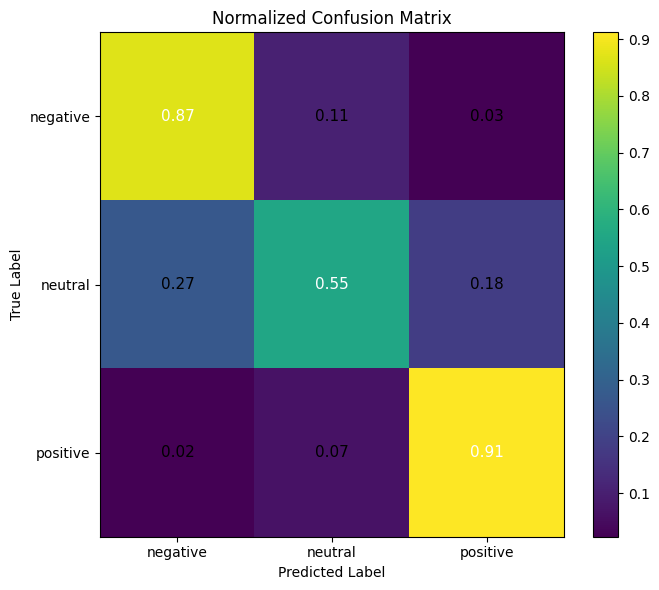

In [23]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["negative", "neutral", "positive"]

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_norm.values, interpolation="nearest", aspect="auto")

# Color bar
plt.colorbar(im)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Normalized Confusion Matrix")

# Display values inside cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_norm.iloc[i, j] > 0.5 else "black",
            fontsize=11
        )

plt.tight_layout()
plt.show()

In [25]:
error_df = test_output[
    test_output["target_sentiment"] != test_output["predicted_sentiment"]
].copy()

error_df[
    [
        "review_text",
        "target_sentiment",
        "predicted_sentiment",
        "review_stars",
        "categories",
        "city"
    ]
].sample(10, random_state=42)

,review_text,target_sentiment,predicted_sentiment,review_stars,categories,city
96440,Little dirty and unorganized and overpriced.Ev...,positive,neutral,4.0,"Bakeries, Restaurants, Food, Juice Bars & Smoo...",Maryland Heights
199127,I would probably give this place 1.5 stars. We...,negative,neutral,2.0,"Chicken Wings, Restaurants, Nightlife, Barbequ...",New Orleans
58909,Popped in here on a lark as we were waiting on...,neutral,positive,3.0,"Arts & Entertainment, Wineries, Wine Tasting R...",Santa Barbara
18946,I'm giving one extra star because the food is ...,negative,neutral,2.0,"Restaurants, Creperies, Cafes, Sandwiches, Bre...",Nashville
167102,The food had a good portion but sadly it had n...,neutral,negative,3.0,"Restaurants, Chinese",Tucson
4488,"Had lunch there with a friend today, was very ...",negative,neutral,2.0,"Restaurants, American (New), Nightlife, Breakf...",Mullica Hill
187845,So let's start off I really wanted to give the...,positive,neutral,4.0,"Steakhouses, Seafood, Restaurants, Desserts, A...",Tampa
81194,"Based on rave reviews from friends in Phoenix,...",positive,neutral,5.0,"Salad, Restaurants, Vegetarian, Breakfast & Br...",Tucson
2601,Some of the top Drs and staff in the area. Alw...,positive,neutral,4.0,"Pets, Veterinarians",Tampa
197252,I'm The shrimp and grits were not even enough ...,negative,neutral,2.0,"Southern, Event Planning & Services, Restauran...",New Orleans
